In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    r"C:/Users/traor/Documents/Case_Study/Cyclistic_Capstone/data/cleaned/cyclistic_cleaned.csv",
    parse_dates=["started_at", "ended_at"]
)

print(df.shape)

(5932285, 19)


member_casual   casual   member
rideable_type                  
classic_bike    634916  1284925
electric_bike  1481697  2530747


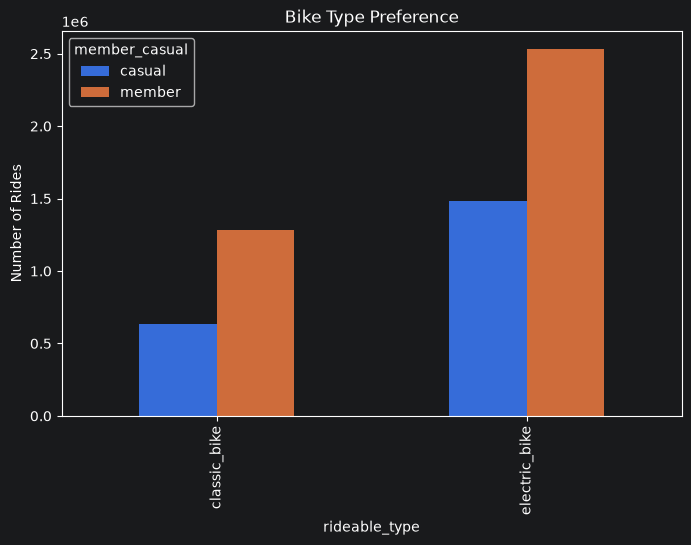

In [2]:
bike_type = (
    df.groupby(["rideable_type", "member_casual"])
      .size()
      .unstack()
)

print(bike_type)

bike_type.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Bike Type Preference")
plt.ylabel("Number of Rides")
plt.show()

## Finding 1: Bike Type Preference

### Observation
Electric bikes are the most popular bike type for both annual members and casual riders. Classic bikes are used less frequently, and docked bikes are rarely used.

### Business Interpretation
The strong preference for electric bikes suggests that riders value convenience and ease of travel. Both rider groups appear to favor electric bikes over traditional bicycles.

### Recommendation
Cyclistic should continue investing in and maintaining its electric bike fleet while highlighting electric bike access as a benefit of annual memberships.

start_station_name
Navy Pier                             60880
DuSable Lake Shore Dr & Monroe St     41589
Michigan Ave & Oak St                 36614
DuSable Lake Shore Dr & North Blvd    35603
Canal St & Madison St                 29563
Wells St & Concord Ln                 28939
State St & Chicago Ave                28657
Theater on the Lake                   28323
Wells St & Elm St                     27607
Millennium Park                       27114
Name: count, dtype: int64


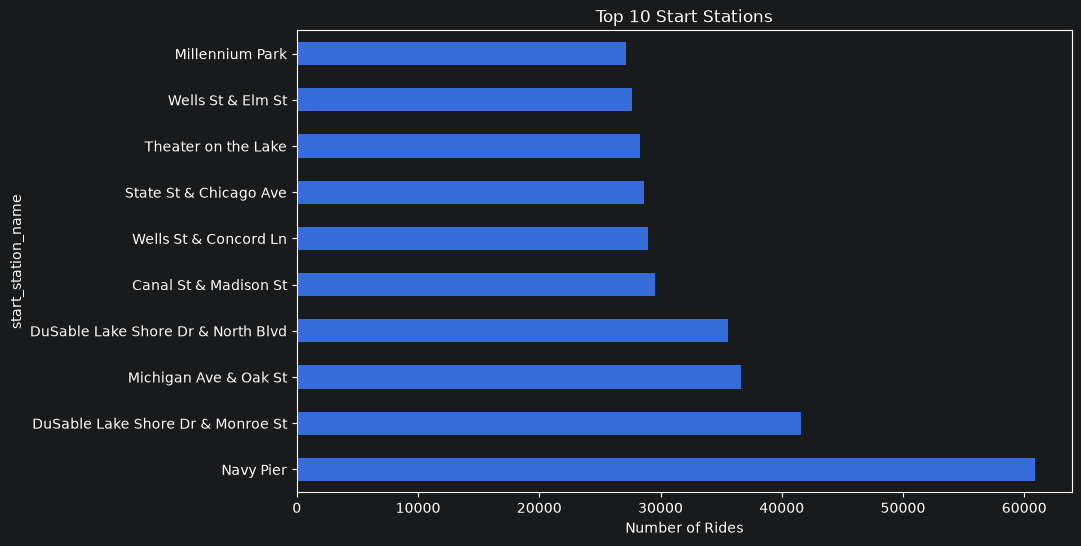

In [9]:
top_start = (
    df["start_station_name"]
      .value_counts()
      .head(10)
)

print(top_start)

top_start.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 Start Stations")
plt.xlabel("Number of Rides")
plt.show()

## Finding 2: Most Popular Start Stations

### Observation
A small number of stations account for a large share of all rides. Stations such as Streeter Dr & Grand Ave and Wells St & Concord Ln appear among the busiest locations.

### Business Interpretation
Popular start stations experience consistently high rider traffic and represent key locations where customers begin their trips.

### Recommendation
Cyclistic should place membership advertisements, digital displays, or promotional events at these high-traffic stations to maximize visibility.

end_station_name
Navy Pier                             60277
DuSable Lake Shore Dr & Monroe St     39524
DuSable Lake Shore Dr & North Blvd    36547
Michigan Ave & Oak St                 36161
Theater on the Lake                   29207
Canal St & Madison St                 29175
Wells St & Concord Ln                 28831
State St & Chicago Ave                28726
Wells St & Elm St                     27167
Millennium Park                       27056
Name: count, dtype: int64


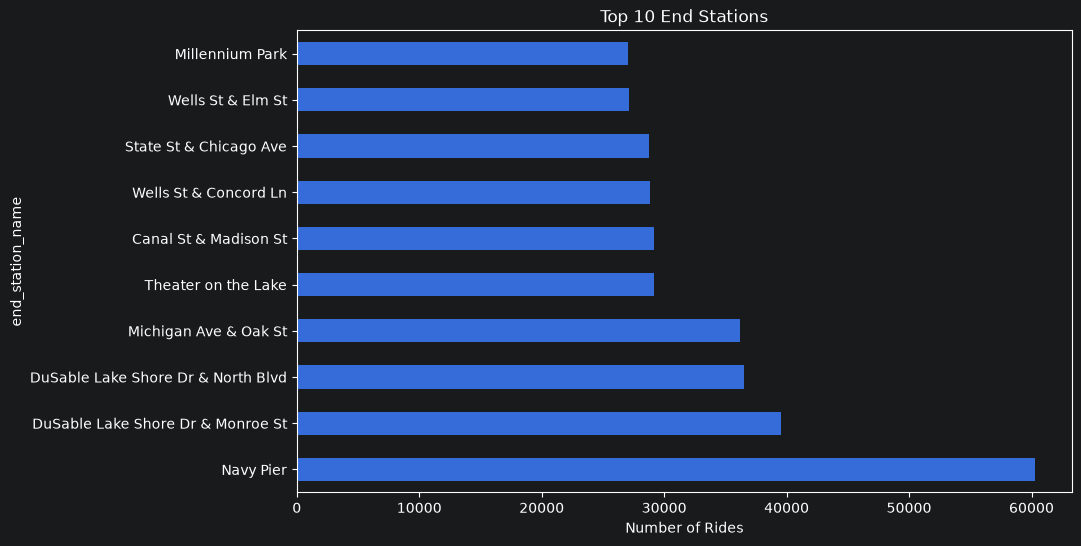

In [15]:
top_end = (
    df["end_station_name"]
      .value_counts()
      .head(10)
)

print(top_end)

top_end.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top 10 End Stations")
plt.xlabel("Number of Rides")
plt.show()

## Finding 3: Most Popular End Stations

### Observation
The busiest end stations closely resemble the busiest start stations, indicating consistent travel demand across these locations.

### Business Interpretation
These stations serve as important transportation hubs where many trips conclude.

### Recommendation
Cyclistic should ensure bike availability at these stations and consider promoting memberships near these destinations.

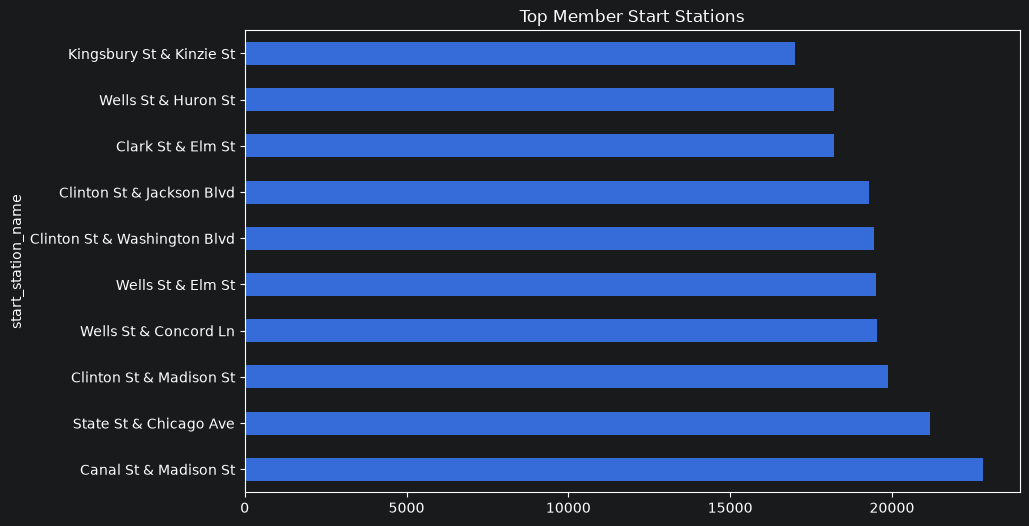

In [20]:
member_station = (
    df[df["member_casual"]=="member"]
      ["start_station_name"]
      .value_counts()
      .head(10)
)

member_station.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Member Start Stations")
plt.show()

## Finding 4: Member Riding Locations

### Observation
Annual members frequently begin rides at stations located near business districts and commuter corridors.

### Business Interpretation
This supports the conclusion that members primarily use Cyclistic bikes for commuting and routine transportation.

### Recommendation
Marketing efforts targeting professionals and commuters could emphasize the convenience and cost savings of annual memberships.

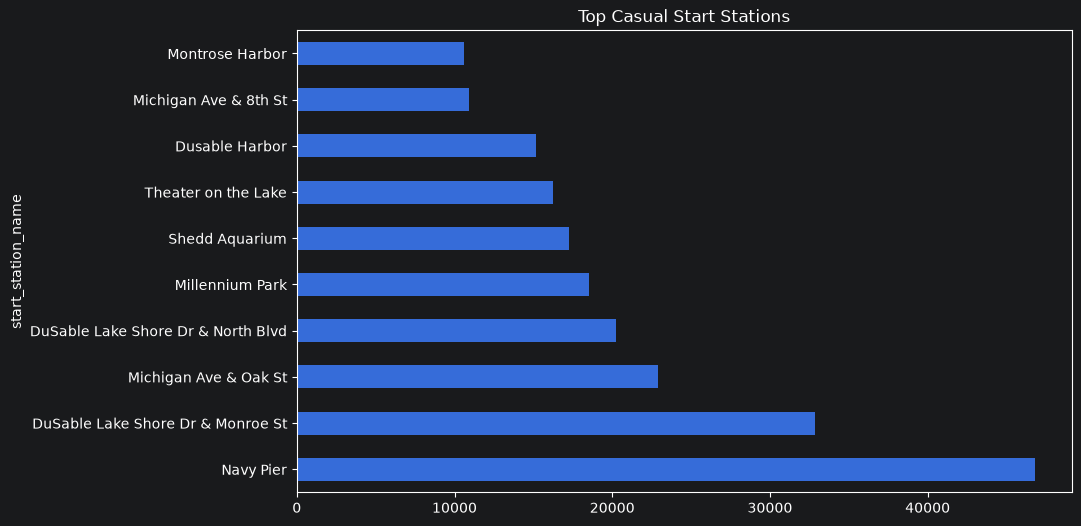

In [24]:
casual_station = (
    df[df["member_casual"]=="casual"]
      ["start_station_name"]
      .value_counts()
      .head(10)
)

casual_station.plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Casual Start Stations")
plt.show()

## Finding 5: Casual Riding Locations

### Observation
Casual riders frequently begin rides near parks, tourist destinations, and recreational areas.

### Business Interpretation
Casual riders are more likely to use bikes for sightseeing, recreation, and leisure rather than daily commuting.

### Recommendation
Cyclistic could advertise annual memberships near recreational areas while promoting benefits that extend beyond leisure riding.

day_of_week
Monday       15.160562
Tuesday      13.863771
Wednesday    13.683427
Thursday     14.122670
Friday       15.772062
Saturday     18.811691
Sunday       19.044702
Name: ride_length, dtype: float64


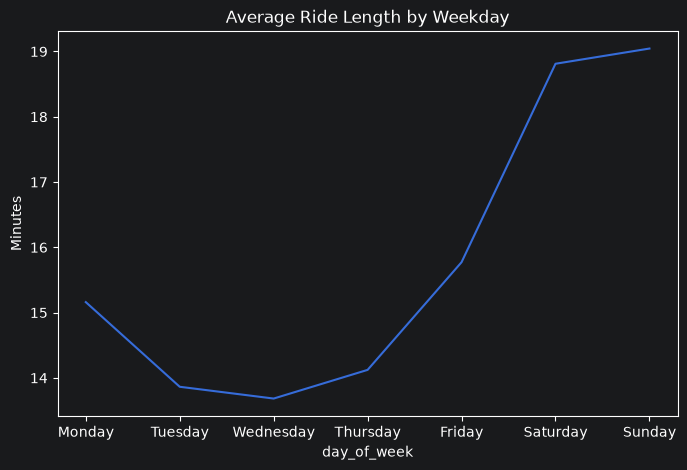

In [27]:
ride_weekday = (
    df.groupby("day_of_week")["ride_length"]
      .mean()
      .reindex([
          "Monday","Tuesday","Wednesday",
          "Thursday","Friday",
          "Saturday","Sunday"
      ])
)

print(ride_weekday)

ride_weekday.plot(
    figsize=(8,5)
)

plt.title("Average Ride Length by Weekday")
plt.ylabel("Minutes")
plt.show()

## Finding 6: Ride Length by Weekday

### Observation
Average ride length increases substantially during weekends, with Saturday and Sunday having the longest trips.

### Business Interpretation
Longer weekend rides suggest that riders use Cyclistic primarily for recreational activities during weekends.

### Recommendation
Weekend promotions encouraging repeat usage and discounted annual memberships may help convert casual riders into long-term customers.

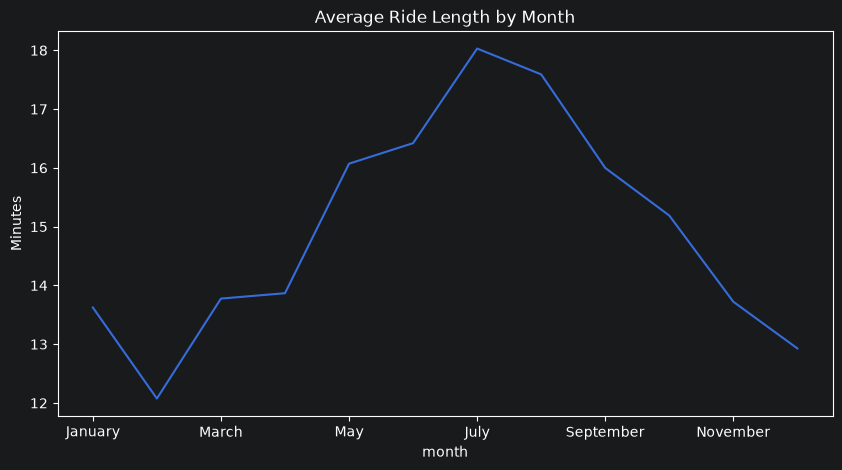

In [29]:
ride_month = (
    df.groupby("month")["ride_length"]
      .mean()
      .reindex([
          "January","February","March","April",
          "May","June","July","August",
          "September","October","November","December"
      ])
)

ride_month.plot(
    figsize=(10,5)
)

plt.title("Average Ride Length by Month")
plt.ylabel("Minutes")
plt.show()

## Finding 7: Ride Length by Month

### Observation
Ride duration gradually increases during spring, reaches its highest level during the summer months, and declines during fall and winter.

### Business Interpretation
Warmer weather encourages longer recreational trips, especially among casual riders.

### Recommendation
Cyclistic should launch seasonal membership campaigns during late spring and early summer when customers are most engaged with the service.

# Overall Findings

Based on the exploratory and advanced analyses, several clear differences exist between annual members and casual riders:

1. Annual members complete substantially more rides than casual riders.
2. Casual riders take significantly longer trips.
3. Members ride consistently throughout the workweek, while casual riders concentrate their riding on weekends.
4. Ridership increases during the summer and decreases during winter.
5. Electric bikes are the preferred bike type for both rider groups.
6. Popular stations provide valuable opportunities for targeted membership marketing.

These findings suggest that casual riders primarily use Cyclistic for leisure, whereas annual members use the service for regular transportation. Marketing strategies should focus on demonstrating the value of annual memberships for frequent and recreational riders alike.